# Notebook 61: Interpolating from MESA grids to a large population

In [1]:
# nb_id is used to identify this notebook's output files (i.e., figures) if there are any
# it should match 
# the first two digits in the notebook's title
nb_id = 61

## Imports

In [2]:

from pathlib import Path
from math import isnan, nan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm, to_rgba
from matplotlib.lines import Line2D
from functools import partial

import astropy.units as u
import astropy.constants as ct
from astropy.cosmology import WMAP9 as cosmo
from scipy.signal import find_peaks
from scipy.interpolate import interp1d, RegularGridInterpolator
from scipy.stats import linregress

from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

import mesa_reader as mr
import mesaPlot as mp
import tulips as tp

import sys
sys.path.append('..')
from src.binary import eggleton_rl1_radius, a_from_p, p_from_a, marchant_l2_radius
from src.util import DATA_DIR, MESA_DATA_DIR, build_bump35_cmap, build_logbump35_cmap

plt.style.use('./plotstyle.mplstyle')
pd.set_option('display.max_columns', None)

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <

In [3]:
FIGURE_FOLDER = Path(f'./output/nb{nb_id}/figures')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

In [4]:
plt.style.use('./plotstyle.mplstyle')

## Definitions

### Constants

In [5]:
Z_SUN = 0.017
t_h = cosmo.age(0).to(u.yr).value

### Utilities

In [6]:
def savefig(fig, fname):
    """Saves png, pdf and eps figure files to a nb-specific folder."""
    fname = f'nb{nb_id}_{fname}'
    plt.savefig(FIGURE_FOLDER/(fname+'.png'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.pdf'), bbox_inches='tight')
    plt.savefig(FIGURE_FOLDER/(fname+'.eps'), bbox_inches='tight')

In [7]:
def normarr(arr):
    return (arr-min(arr))/(max(arr)-min(arr))

In [8]:
def get_model_folder(model_id, project_folder, verbose=True):
    """Finds model folder given its id."""
    matches = list(project_folder.glob(f'{model_id}*'))
    
    if len(matches) > 1:
        if verbose:
            print('\n'.join((
                f'Multiple matches for id {model_id} found in {project_folder}:',
                *[str(match) for match in matches]
            )))
        return
    elif len(matches) != 0:
        match = matches[0]
        if verbose:
            print(f'Found match {match}')
        return match
    else:
        if verbose:
            print(f'No matches found in {project_folder}')
        return           

In [9]:
def get_model_dict(grid_folder):
    """Given a model folder, loads the paths of specific stars into a 
    m1, p_orb dictionary."""
    d = dict()
    for model_folder in grid_folder.glob('m*_w*'):
        if model_folder.suffix == '.log':
            continue
        try:
            m, p, w = model_folder.name.replace('d', 'e').split('_')
            w = float(w.lstrip('w'))
            p = f'{float(p.lstrip("p")):.2f}'      
        except ValueError:
            m, w = model_folder.name.replace('d', 'e').split('_')   
            w = float(w.lstrip('w'))
            p = (2*np.pi/w) / (60*60*24)
        m = f'{float(m.lstrip("m")):.1f}'
        
        if m not in d.keys():
            d[m] = dict()
        d[m][p] = model_folder
    return d

In [10]:
def mesareader_operator(expression, object_to_call='h'):
    """Converts strings into operations between mesareader columns.
    
    Supports summation, subtraction, multiplication, division and exp10."""
    operations = ['+', '-', '*', '/', '^', 'E', '(', ')', ',']
    
    mr_expression = ''
    attr = ''
    char_i = 0
    while char_i < len(expression):
        char = expression[char_i]
        if char not in operations:
            mr_expression += f'{object_to_call}.__getattr__("{char}'
        else:
            if char == '^':
                char = '10**'
            elif char == 'E':
                char = 'gamma_e('
            mr_expression += f'{char}{object_to_call}.__getattr__("'
        char_i += 1
        char = expression[char_i]
        while char not in operations+['']:
            attr += char
            char_i += 1
            try:
                char = expression[char_i]
            except IndexError:
                char = ''
        if char == '^':
            char = '10**'
        elif char == 'E':
                char = 'gamma_e('
        attr = f'{attr}"){char}'
        mr_expression += attr
        attr = ''
        char_i += 1
            
    return mr_expression


In [11]:
def draw_mass_sample(
    res=int(1e8),
    min_m=20,
    max_m=300,
    min_p=0.1,
    max_p=4,
    min_mfinal=20,
    max_mfinal=50,
    mfinal_bin_width=0.2
):
    sample_masses = np.linspace(min_m, max_m, res)
    sample_probs = sample_masses**-2.3/np.sum(sample_masses**-2.3)
    sample_masses = np.random.choice(sample_masses, p=sample_probs, size=int(res/100))

    sample_periods = np.linspace(np.log10(min_p), np.log10(max_p), res)
    sample_probs = np.ones(res)/res
    sample_periods = 10.**np.random.choice(sample_periods, p=sample_probs, size=int(res/100))

    sample_zams_rs = np.array([l2_mzams_rzams_interpolator(m, p) for m, p in zip(sample_masses, sample_periods)])

    sample_mcores = np.zeros(int(res/100))

    sample_ = np.array([sample_masses, sample_periods, sample_zams_rs, sample_mcores]).T
    zams_l2of_sample = set_mcores(sample_).copy()
    
    mass_draw = zams_l2of_sample[:, 3]
    mass_draw = mass_draw[~np.isnan(mass_draw)]

    bins = np.arange(min_mfinal, max_mfinal+mfinal_bin_width, mfinal_bin_width)
    hist, bins = np.histogram(mass_draw, density=True, bins=bins)
    centers = np.array([(bin0+bin1)/2 for bin0, bin1 in zip(bins[:-1], bins[1:])])
    mode = centers[np.argmax(hist)]
    
    return zams_l2of_sample, mode

In [12]:
def is_of(r, m, p, q=1, kind='RL'):
    a = a_from_p(p, m, q)
    if kind == 'merger':
        of_a = a.to(u.Rsun).value
    elif kind == 'RL':
        of_a = eggleton_rl1_radius(a, q).to(u.Rsun).value
    elif kind == 'L2':
        of_a = marchant_l2_radius(a, q).to(u.Rsun).value
    elif kind == 'none':
        of_a = np.inf
    else:
        raise ValueError(f'kind {kind} not recognized')
    if of_a <= r:
        isof = True
    else:
        isof = False

    return isof

## Generating an interpolated population

Let us load and organize our grids first.

In [14]:
def get_model_folder(model_id, verbose=True):
    """Finds model folder given its id."""
    matches = list(PROJECT_FOLDER.glob(f'{model_id}*'))
    
    if len(matches) > 1:
        if verbose:
            print('\n'.join((
                f'Multiple matches for id {model_id} found in {PROJECT_FOLDER}:',
                *[str(match) for match in matches]
            )))
        return
    elif len(matches) != 0:
        match = matches[0]
        if verbose:
            print(f'Found match {match}')
        return match
    else:
        if verbose:
            print(f'No matches found in {PROJECT_FOLDER}')
        return           

In [15]:
def get_model_dict(grid_folder):
    """Given a model folder, loads the paths of specific stars into a 
    m1, p_orb dictionary."""
    d = dict()
    for model_folder in grid_folder.glob('m*_p*_w*'):
        if model_folder.suffix == '.log':
            continue
        m, p, w = model_folder.name.replace('d', 'e').split('_')
        w = float(w.lstrip('w'))
        p = f'{float(p.lstrip("p")):.2f}'      
        m = f'{float(m.lstrip("m")):.1f}'
        
        if m not in d.keys():
            d[m] = dict()
        d[m][p] = model_folder
    return d

In [16]:
model_ids = np.arange(0, 9, 1)
model_ids = np.array([f'{id:04d}' for id in model_ids])

In [17]:
PROJECT_BASE = MESA_DATA_DIR / '00_fiducial'

# Each entry: { label used in all_model_dicts : (variable suffix, folder name) }
metallicity_map = {
  #  '0.0005': ('0005zsun', '0000_ZdivZsun_5d-03'),
  #  '0.001':  ('001zsun',  '0001_ZdivZsun_1d-02'),
    '0.002':  ('002zsun',  '0002_ZdivZsun_2d-02'),
    '0.004':  ('004zsun',  '0003_ZdivZsun_4d-02'),
    '0.008':  ('008zsun',  '0004_ZdivZsun_8d-02'),
    '0.01':   ('01zsun',   '0005_ZdivZsun_1d-01'),
    '0.02':   ('02zsun',   '0006_ZdivZsun_2d-01'),
    '0.03':   ('03zsun',   '0007_ZdivZsun_3d-01'),
    '0.04':   ('04zsun',   '0008_ZdivZsun_4d-01'),
}

# initialize container for final dict
all_model_dicts = {}

for z_label, (suffix, folder_name) in metallicity_map.items():
    PROJECT_FOLDER = PROJECT_BASE / folder_name

    model_ids = np.arange(1, 25, 1)
    model_ids = np.array([f'{id:03d}' for id in model_ids])
    model_folders = np.array([get_model_folder(id) for id in model_ids])
    model_dicts = np.array([get_model_dict(folder) for folder in model_folders])
    model_labels = np.array([f'${float(id):0f}\\,\\mathrm{{M}}_\\odot$' for id in model_ids])

    # create a variable named model_dicts_XXXzsun dynamically
    globals()[f'model_dicts_{suffix}'] = model_dicts

    # add entry to final dict (same structure as before)
    all_model_dicts[z_label] = {
    k: v
    for d in model_dicts
    for k, v in d.items()
}



Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/001_m10
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/002_m15
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/003_m20
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/004_m25
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/005_m30
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/006_m35
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/007_m40
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/008_m45
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/009_m50
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducia

Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/012_m80
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/013_m90
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/014_m100
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/015_m120
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/016_m140
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/017_m160
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/018_m180
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/019_m200
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02/020_m220
Found match /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_

In [18]:
core_props_df = pd.read_hdf(DATA_DIR/'00_fiducial_core_props_df.h5')
core_props_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6720 entries, 0 to 6719
Columns: 107 entries, z_key to is_crash
dtypes: bool(9), float64(97), object(1)
memory usage: 5.1+ MB


In [19]:
stages = ['zams', 'wr0', 'wr1', 'tams', 'tahems', 'cdepl', 'odepl', 'f']

In [20]:
def set_x(row, stage='f'):
    j = 10.**row[f'log_j_{stage}'] * u.g * u.cm**2 / u.s
    m = row[f'm_{stage}'] * u.Msun
    x = ct.c * j / ct.G / m**2
    x = x.to(u.dimensionless_unscaled).value
    return x

for stage in stages:
    core_props_df[f'x_{stage}'] = core_props_df.apply(lambda row: set_x(row, stage=stage), axis=1)

In [21]:
def set_min_x(row, stage='f'):
    i = row[f'inertia_{stage}'] * u.g * u.cm**2
    p = row[f'p_orb_{stage}'] * u.d
    m = row[f'm_{stage}'] * u.Msun
    w = 2*np.pi / p.to(u.s)
    min_j = i * w
    min_x = ct.c * min_j / ct.G / m**2
    min_x = min_x.to(u.dimensionless_unscaled).value
    return min_x

for stage in stages:
    core_props_df[f'min_x_{stage}'] = core_props_df.apply(lambda row: set_min_x(row, stage=stage), axis=1)

In [22]:
def set_v_rot_surf(row, stage='f'):
    r = row[f'r_{stage}'] * u.Rsun
    p = row[f'p_orb_{stage}'] * u.d
    v_rot = 2*np.pi*r / p.to(u.s)
    v_rot = v_rot.to(u.km/u.s).value
    return v_rot

for stage in stages:
    core_props_df[f'v_rot_surf_{stage}'] = core_props_df.apply(lambda row: set_v_rot_surf(row, stage=stage), axis=1)

In [23]:
def set_v_rot_div_v_crit(row, stage='f'):
    v_rot = row[f'v_rot_surf_{stage}'] * u.km/u.s
    m = row[f'm_{stage}'] * u.Msun
    r = row[f'r_{stage}'] * u.Rsun
    v_crit = np.sqrt(ct.G * m / r).to(u.km/u.s)
    v_rot_div_v_crit = (v_rot / v_crit).to(u.dimensionless_unscaled).value
    return v_rot_div_v_crit

for stage in stages:
    core_props_df[f'v_rot_div_v_crit_{stage}'] = core_props_df.apply(lambda row: set_v_rot_div_v_crit(row, stage=stage), axis=1)

In [24]:
z_axis = core_props_df.z_key.unique()
z_axis = z_axis[np.float64(z_axis).argsort()]

In [25]:
core_props_df.is_che = core_props_df.is_che.astype(bool)

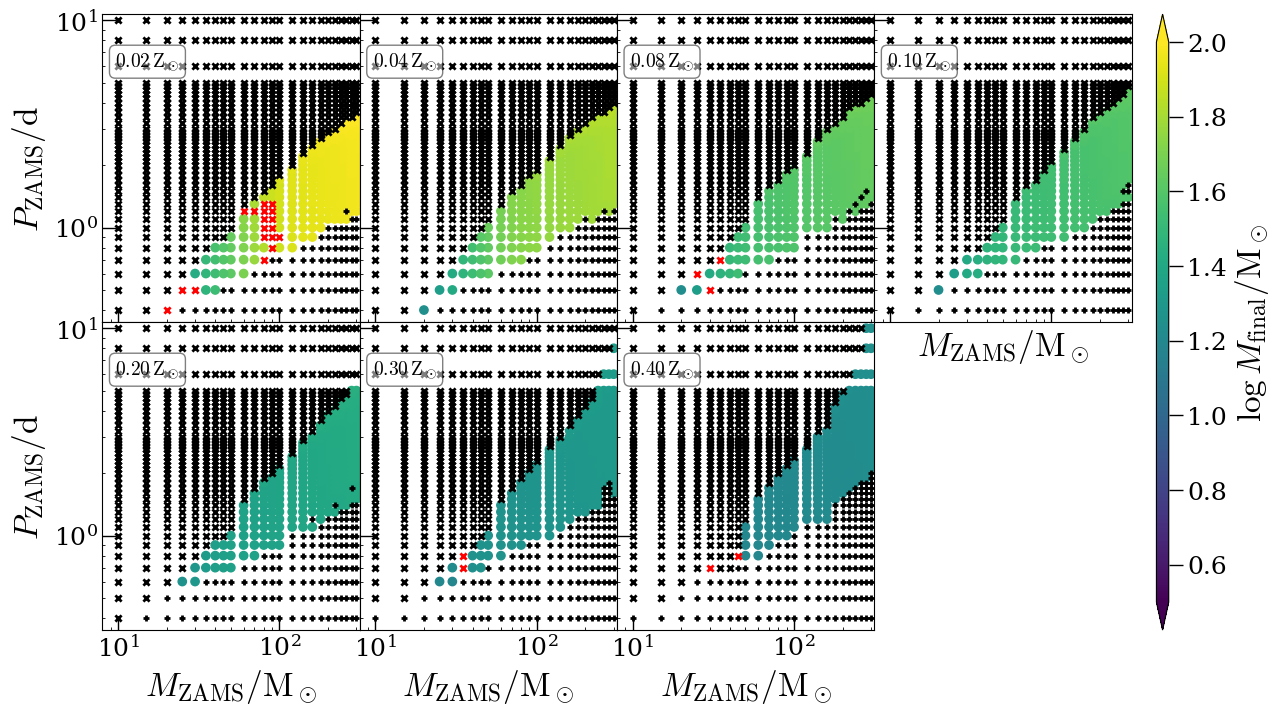

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0, wspace=0)
mf_min = 0.5
mf_max = 2
cmap = cm.viridis

z_plot = core_props_df.z_key.unique()
z_plot = z_plot[np.float64(z_plot).argsort()]

first_empty_ax_i = 0
for ax, z_key in zip(axes.flatten(), z_plot):
    ax.scatter(
        core_props_df[core_props_df.z_key==z_key].m_zams,
        core_props_df[core_props_df.z_key==z_key].p_spin_zams,
        c=cmap(
            (np.log10(core_props_df[core_props_df.z_key==z_key].m_f) - mf_min) / (mf_max-mf_min))
    )
    ax.text(0.05, 0.88, f'${float(z_key):.2f}\\,\\mathrm{{Z}}_\\odot$', va='top', ha='left', transform=ax.transAxes, fontsize=14,
            bbox={
                'boxstyle': 'round',
                'facecolor': 'white',
                'edgecolor': 'black',
                'alpha': 0.5
            })
    
    crash_df = core_props_df[core_props_df.is_crash]
    ax.scatter(
        crash_df[crash_df.z_key==z_key].m_zams,
        crash_df[crash_df.z_key==z_key].p_spin_zams,
        marker='x', c='red', s=20, label='crash'
    )
    
    nonche_df = core_props_df[~core_props_df.is_che]
    ax.scatter(
        nonche_df[nonche_df.z_key==z_key].m_zams,
        nonche_df[nonche_df.z_key==z_key].p_spin_zams,
        marker='x', c='black', s=20, label='non-che'
    )
    
    crit_df = core_props_df[core_props_df.is_crit_at_zams]
    ax.scatter(
        crit_df[crit_df.z_key==z_key].m_zams,
        crit_df[crit_df.z_key==z_key].p_spin_zams,
        marker='+', c='black', s=20, label='crit'
    )
    first_empty_ax_i += 1
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_ylim(0.35, 10.7)
    ax.set_xlim(8)
    ax.set_xticks([10, 100, 200])
    
    ax.set_xscale('log')
    ax.set_yscale('log')
for i in range(axes.shape[1]):
    axes[1, i].set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)
for i in range(axes.shape[0]):
    axes[i, 0].set_ylabel('$P_\\mathrm{ZAMS}/\\mathrm{d}$', fontsize=24)
axes[0, -1].set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)

for ax in axes.flatten()[first_empty_ax_i:]:
    ax.axis('off')
    
#fig.text(0.06, 0.5, '$P_\\mathrm{ZAMS}/\\mathrm{d}$', fontsize=24, rotation=90)


sm = cm.ScalarMappable(norm=Normalize(vmin=mf_min, vmax=mf_max), cmap=cmap)
cb = fig.colorbar(sm, ax=axes, orientation='vertical', extend='both', pad=0.02, aspect=50)
cb.set_label('$\\log M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24)

#savefig(fig, 'che_windows_over_z_viridis')

/tmp/ipykernel_127838/2962637885.py:196: MatplotlibDeprecationWarning: hatch must consist of a string of "*+-./OX\ox|" or None, but found the following invalid values "en". Passing invalid values is deprecated since 3.4 and will become an error in 3.9.
  Patch(facecolor=crash_color, edgecolor=(0,0,0,0.3), hatch=crash_hatch, label='Crash'),


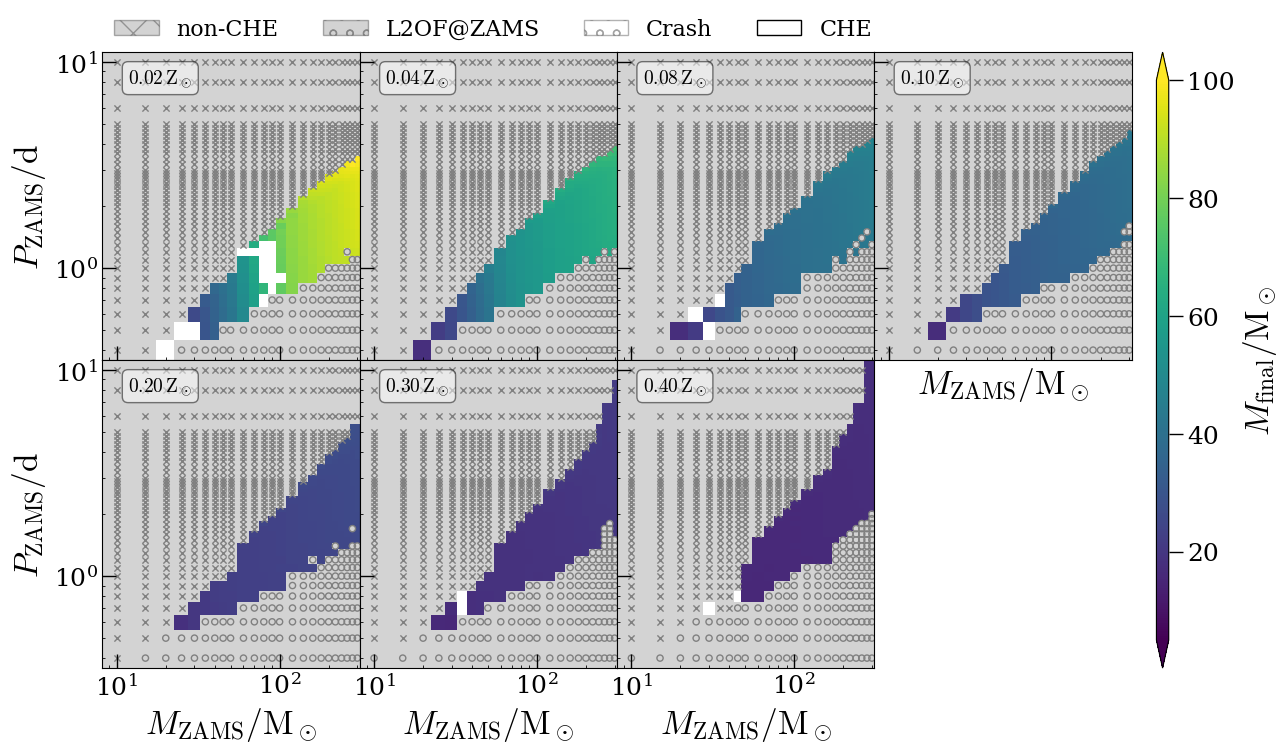

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0, wspace=0)
mf_min = 5
mf_max = 100
cmap = cm.viridis

z_plot = core_props_df.z_key.unique()
z_plot = z_plot[np.float64(z_plot).argsort()]

first_empty_ax_i = 0

def edges_halfway_log(arr):
    """Return edges halfway between sorted unique arr values using log10 midpoints.
       arr: numpy array of positive values.
    """
    arr = np.asarray(arr)
    # only keep finite positive values
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if arr.size == 0:
        return None
    # sorted unique
    u = np.unique(arr)
    if u.size == 1:
        # single value: make small symmetric edges around it (10% in log space)
        v = u[0]
        # avoid log10 of zero or negative
        dl = 0.1 * np.log10(v) if v > 0 else 0.1
        e_log = np.array([np.log10(v) - dl, np.log10(v) + dl])
        return 10.0 ** e_log
    # convert to log-space and get midpoints
    u_log = np.log10(u)
    mid_log = 0.5 * (u_log[:-1] + u_log[1:])
    # extend the first and last edges by reflecting the adjacent interval
    first_edge = u_log[0] - (mid_log[0] - u_log[0])
    last_edge  = u_log[-1] + (u_log[-1] - mid_log[-1])
    edges_log = np.concatenate(([first_edge], mid_log, [last_edge]))
    return 10.0 ** edges_log

# colors for overlays
nonche_color = "lightgray"  # dark greenish-gray
nonche_hatch = "x"
crit_color   = "lightgray"  # dark neutral gray
crit_hatch   = "o"
crash_color  = "white"
crash_hatch  = "none"

for ax, z_key in zip(axes.flatten(), z_plot):
    sel = core_props_df[core_props_df.z_key == z_key]
    if len(sel) == 0:
        first_empty_ax_i += 1
        continue

    # data coords (original linear values)
    x = sel.m_zams.to_numpy()
    y = sel.p_spin_zams.to_numpy()
    # the colour quantity we want in bins: m_f
    colvals = sel.m_f.to_numpy()

    x_edges = edges_halfway_log(x)
    y_edges = edges_halfway_log(y)
    if x_edges is None or y_edges is None:
        # fallback: scatter if something pathological happened
        ax.scatter(
            x, y,
            c=cmap((colvals - mf_min) / (mf_max - mf_min))
        )
    else:
        # digitize points into bin indices (indices run 1..len(edges)-1)
        ix = np.digitize(x, x_edges) - 1
        iy = np.digitize(y, y_edges) - 1
        nx = len(x_edges) - 1
        ny = len(y_edges) - 1

        # accumulate sum and count per bin to compute mean
        sum_grid = np.zeros((ny, nx), dtype=float)
        count_grid = np.zeros((ny, nx), dtype=float)
        valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
        for (i_x, i_y, v, ok) in zip(ix, iy, colvals, valid):
            if not ok:
                continue
            sum_grid[i_y, i_x] += v
            count_grid[i_y, i_x] += 1.0

        # average, put NaN where count==0
        with np.errstate(invalid='ignore', divide='ignore'):
            avg_grid = sum_grid / count_grid
        avg_grid[count_grid == 0] = np.nan

        # main background: binned m_f
        norm = Normalize(vmin=mf_min, vmax=mf_max)
        pcm = ax.pcolormesh(
            x_edges, y_edges, avg_grid,
            cmap=cmap, norm=norm,
            shading='auto'
        )

        # --- prepare overlay grids for special categories ---
        # select the special-point subsets for this z_key
        nonche_sel = core_props_df[(~core_props_df.is_che) & (core_props_df.z_key == z_key)]
        crit_sel   = core_props_df[core_props_df.is_crit_at_zams & (core_props_df.z_key == z_key)]
        crash_sel  = core_props_df[core_props_df.is_crash & (core_props_df.z_key == z_key)]

        def make_overlay_grid(df):
            """Return a grid with 1.0 where df points fall into a bin, NaN elsewhere."""
            grid = np.full_like(avg_grid, np.nan)
            if len(df) == 0:
                return grid
            xs = df.m_zams.to_numpy()
            ys = df.p_spin_zams.to_numpy()
            ixs = np.digitize(xs, x_edges) - 1
            iys = np.digitize(ys, y_edges) - 1
            for i_x, i_y in zip(ixs, iys):
                if 0 <= i_x < nx and 0 <= i_y < ny:
                    grid[i_y, i_x] = 1.0
            return grid

        nonche_grid = make_overlay_grid(nonche_sel)
        crit_grid   = make_overlay_grid(crit_sel)
        crash_grid  = make_overlay_grid(crash_sel)

        # draw overlays as solid-color bins (order sets visual priority)
        # crash (red) on top
        if np.any(~np.isnan(crash_grid)):
            ax.pcolormesh(
                x_edges, y_edges, crash_grid,
                cmap=ListedColormap([crash_color]),
                norm=Normalize(vmin=0.0, vmax=1.0),
                shading='auto'
            )
        # then crit
        if np.any(~np.isnan(crit_grid)):
            ax.pcolormesh(
                x_edges, y_edges, crit_grid,
                cmap=ListedColormap([crit_color]),
                norm=Normalize(vmin=0.0, vmax=1.0),
                shading='auto'
            )
        ax.scatter(
            crit_sel.m_zams,
            crit_sel.p_spin_zams,
            marker='o', edgecolor='gray', facecolor='none', s=20, label='crit', linewidths=1
        )
        
        # then nonche
        if np.any(~np.isnan(nonche_grid)):
            ax.pcolormesh(
                x_edges, y_edges, nonche_grid,
                cmap=ListedColormap([nonche_color]),
                norm=Normalize(vmin=0.0, vmax=1.0),
                shading='auto'
            )
        ax.scatter(
            nonche_sel.m_zams,
            nonche_sel.p_spin_zams,
            marker='x', c='gray', s=20, linewidths=1, label='non-che'
            )
            


    # annotate the panel
    ax.text(0.1, 0.95, f'${float(z_key):.2f}\\,\\mathrm{{Z}}_\\odot$', va='top', ha='left', transform=ax.transAxes, fontsize=14,
            bbox={'boxstyle': 'round','facecolor': 'white','edgecolor': 'black','alpha': 0.5}, zorder=10)

    first_empty_ax_i += 1
    ax.tick_params(axis='both', which='both', direction='in')
    #ax.set_ylim(0.35, 10.7)
    #ax.set_xlim(8)
    ax.set_xticks([10, 100, 200])

    ax.set_xscale('log')
    ax.set_yscale('log')

# (the rest of your axis labels / colorbar code)
for i in range(axes.shape[1]):
    axes[1, i].set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)
for i in range(axes.shape[0]):
    axes[i, 0].set_ylabel('$P_\\mathrm{ZAMS}/\\mathrm{d}$', fontsize=24)
axes[0, -1].set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)

for ax in axes.flatten()[first_empty_ax_i:]:
    ax.axis('off')

sm = cm.ScalarMappable(norm=Normalize(vmin=mf_min, vmax=mf_max), cmap=cmap)
cb = fig.colorbar(sm, ax=axes, orientation='vertical', extend='both', pad=0.02, aspect=50)
cb.set_label('$M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24)

handles = [
    Patch(facecolor=nonche_color, edgecolor=(0,0,0,0.3), hatch=nonche_hatch, label='non-CHE'),
    Patch(facecolor=crit_color, edgecolor=(0,0,0,0.3), hatch=crit_hatch, label='L2OF@ZAMS'),
    Patch(facecolor=crash_color, edgecolor=(0,0,0,0.3), hatch=crash_hatch, label='Crash'),
    Patch(facecolor='white', edgecolor='black', label='CHE')
]
fig.legend(handles=handles, loc='lower left', ncol=len(handles), fontsize=16, bbox_to_anchor=(0.12, 0.87), frameon=False)

#savefig(fig, 'che_windows_hist')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


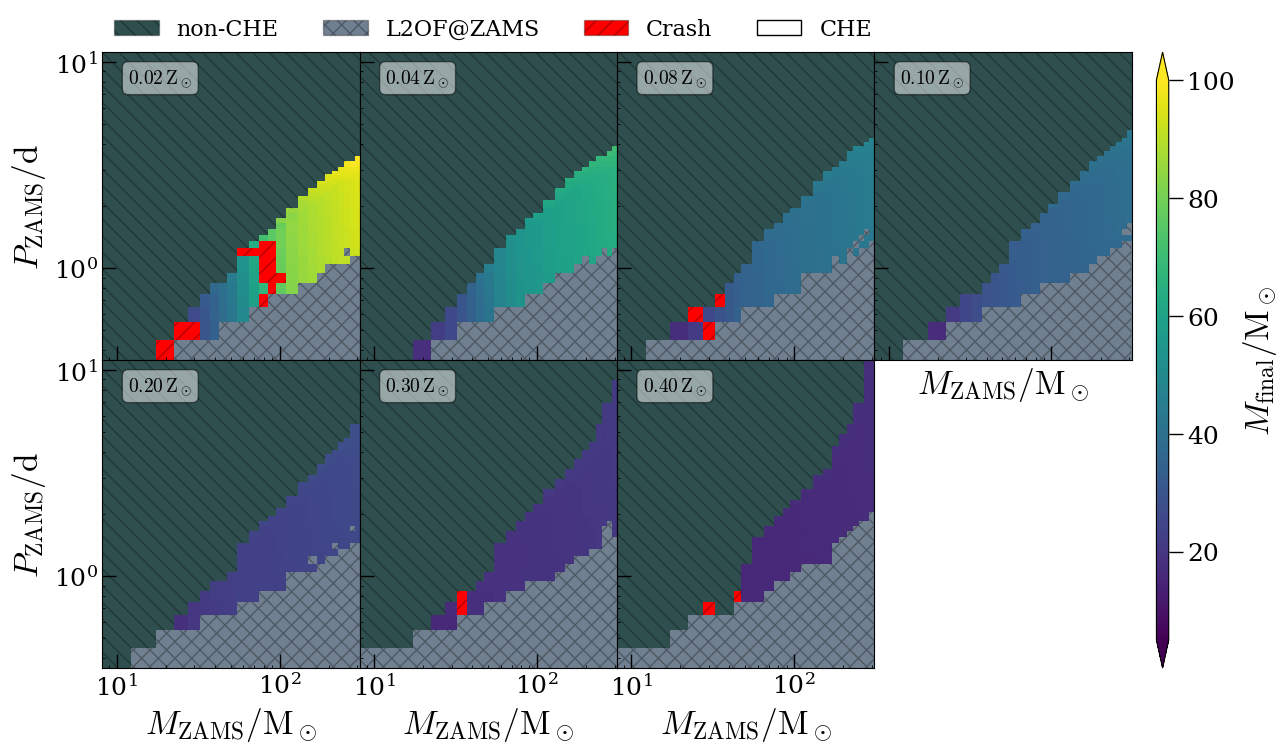

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, ListedColormap
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0, wspace=0)
mf_min = 5
mf_max = 100
cmap = cm.viridis

z_plot = core_props_df.z_key.unique()
z_plot = z_plot[np.float64(z_plot).argsort()]

first_empty_ax_i = 0

def edges_halfway_log(arr):
    """Return edges halfway between sorted unique arr values using log10 midpoints.
       arr: numpy array of positive values.
    """
    arr = np.asarray(arr)
    # only keep finite positive values
    arr = arr[np.isfinite(arr) & (arr > 0)]
    if arr.size == 0:
        return None
    # sorted unique
    u = np.unique(arr)
    if u.size == 1:
        # single value: make small symmetric edges around it (10% in log space)
        v = u[0]
        # avoid log10 of zero or negative
        dl = 0.1 * np.log10(v) if v > 0 else 0.1
        e_log = np.array([np.log10(v) - dl, np.log10(v) + dl])
        return 10.0 ** e_log
    # convert to log-space and get midpoints
    u_log = np.log10(u)
    mid_log = 0.5 * (u_log[:-1] + u_log[1:])
    # extend the first and last edges by reflecting the adjacent interval
    first_edge = u_log[0] - (mid_log[0] - u_log[0])
    last_edge  = u_log[-1] + (u_log[-1] - mid_log[-1])
    edges_log = np.concatenate(([first_edge], mid_log, [last_edge]))
    return 10.0 ** edges_log

# colors for overlays
nonche_color = "darkslategray"  # dark greenish-gray
nonche_hatch = "\\\\"
crit_color   = "slategray"  # dark neutral gray
crit_hatch   = "xx"
crash_color  = "red"
crash_hatch  = "//"

for ax, z_key in zip(axes.flatten(), z_plot):
    sel = core_props_df[core_props_df.z_key == z_key]
    if len(sel) == 0:
        first_empty_ax_i += 1
        continue

    # data coords (original linear values)
    x = sel.m_zams.to_numpy()
    y = sel.p_spin_zams.to_numpy()
    # the colour quantity we want in bins: m_f
    colvals = sel.m_f.to_numpy()

    x_edges = edges_halfway_log(x)
    y_edges = edges_halfway_log(y)
    if x_edges is None or y_edges is None:
        # fallback: scatter if something pathological happened
        ax.scatter(
            x, y,
            c=cmap((colvals - mf_min) / (mf_max - mf_min))
        )
    else:
        # digitize points into bin indices (indices run 1..len(edges)-1)
        ix = np.digitize(x, x_edges) - 1
        iy = np.digitize(y, y_edges) - 1
        nx = len(x_edges) - 1
        ny = len(y_edges) - 1

        # accumulate sum and count per bin to compute mean
        sum_grid = np.zeros((ny, nx), dtype=float)
        count_grid = np.zeros((ny, nx), dtype=float)
        valid = (ix >= 0) & (ix < nx) & (iy >= 0) & (iy < ny)
        for (i_x, i_y, v, ok) in zip(ix, iy, colvals, valid):
            if not ok:
                continue
            sum_grid[i_y, i_x] += v
            count_grid[i_y, i_x] += 1.0

        # average, put NaN where count==0
        with np.errstate(invalid='ignore', divide='ignore'):
            avg_grid = sum_grid / count_grid
        avg_grid[count_grid == 0] = np.nan

        # main background: binned m_f
        norm = Normalize(vmin=mf_min, vmax=mf_max)
        pcm = ax.pcolormesh(
            x_edges, y_edges, avg_grid,
            cmap=cmap, norm=norm,
            shading='auto'
        )

        # --- prepare overlay grids for special categories ---
        # select the special-point subsets for this z_key
        nonche_sel = core_props_df[(~core_props_df.is_che) & (core_props_df.z_key == z_key)]
        crit_sel   = core_props_df[core_props_df.is_crit_at_zams & (core_props_df.z_key == z_key)]
        crash_sel  = core_props_df[core_props_df.is_crash & (core_props_df.z_key == z_key)]

        def make_overlay_grid(df):
            """Return a grid with 1.0 where df points fall into a bin, NaN elsewhere."""
            grid = np.full_like(avg_grid, np.nan)
            if len(df) == 0:
                return grid
            xs = df.m_zams.to_numpy()
            ys = df.p_spin_zams.to_numpy()
            ixs = np.digitize(xs, x_edges) - 1
            iys = np.digitize(ys, y_edges) - 1
            for i_x, i_y in zip(ixs, iys):
                if 0 <= i_x < nx and 0 <= i_y < ny:
                    grid[i_y, i_x] = 1.0
            return grid

        nonche_grid = make_overlay_grid(nonche_sel)
        crit_grid   = make_overlay_grid(crit_sel)
        crash_grid  = make_overlay_grid(crash_sel)

        # draw overlays as solid-color bins (order sets visual priority)
        # crash (red) on top
        if np.any(~np.isnan(crash_grid)):
            ax.pcolormesh(
                x_edges, y_edges, crash_grid,
                cmap=ListedColormap([crash_color]),
                norm=Normalize(vmin=0.0, vmax=1.0),
                shading='auto'
            )
        # then crit
        if np.any(~np.isnan(crit_grid)):
            ax.pcolormesh(
                x_edges, y_edges, crit_grid,
                cmap=ListedColormap([crit_color]),
                norm=Normalize(vmin=0.0, vmax=1.0),
                shading='auto'
            )
        # then nonche
        if np.any(~np.isnan(nonche_grid)):
            ax.pcolormesh(
                x_edges, y_edges, nonche_grid,
                cmap=ListedColormap([nonche_color]),
                norm=Normalize(vmin=0.0, vmax=1.0),
                shading='auto'
            )
            
        if np.any(~np.isnan(crash_grid)):
            Z = np.ma.masked_invalid(crash_grid)
            ax.pcolor(x_edges, y_edges, Z,
                    facecolor='none',
                    edgecolor=(0,0,0,0.3),  # hatch visible
                    hatch=crash_hatch,
                    linewidth=0.0,
                    zorder=7)

        if np.any(~np.isnan(crit_grid)):
            Z = np.ma.masked_invalid(crit_grid)
            ax.pcolor(x_edges, y_edges, Z,
                    facecolor='none',
                    edgecolor=(0,0,0,0.3),
                    hatch=crit_hatch,
                    linewidth=0.0,
                    zorder=6)

        if np.any(~np.isnan(nonche_grid)):
            Z = np.ma.masked_invalid(nonche_grid)
            ax.pcolor(x_edges, y_edges, Z,
                    facecolor='none',
                    edgecolor=(0,0,0,0.3),
                    hatch=nonche_hatch,
                    linewidth=0.0,
                    zorder=5)


    # annotate the panel
    ax.text(0.1, 0.95, f'${float(z_key):.2f}\\,\\mathrm{{Z}}_\\odot$', va='top', ha='left', transform=ax.transAxes, fontsize=14,
            bbox={'boxstyle': 'round','facecolor': 'white','edgecolor': 'black','alpha': 0.5}, zorder=10)

    first_empty_ax_i += 1
    ax.tick_params(axis='both', which='both', direction='in')
    #ax.set_ylim(0.35, 10.7)
    #ax.set_xlim(8)
    ax.set_xticks([10, 100, 200])

    ax.set_xscale('log')
    ax.set_yscale('log')

# (the rest of your axis labels / colorbar code)
for i in range(axes.shape[1]):
    axes[1, i].set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)
for i in range(axes.shape[0]):
    axes[i, 0].set_ylabel('$P_\\mathrm{ZAMS}/\\mathrm{d}$', fontsize=24)
axes[0, -1].set_xlabel('$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)

for ax in axes.flatten()[first_empty_ax_i:]:
    ax.axis('off')

sm = cm.ScalarMappable(norm=Normalize(vmin=mf_min, vmax=mf_max), cmap=cmap)
cb = fig.colorbar(sm, ax=axes, orientation='vertical', extend='both', pad=0.02, aspect=50)
cb.set_label('$M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24)

handles = [
    Patch(facecolor=nonche_color, edgecolor=(0,0,0,0.3), hatch=nonche_hatch, label='non-CHE'),
    Patch(facecolor=crit_color, edgecolor=(0,0,0,0.3), hatch=crit_hatch, label='L2OF@ZAMS'),
    Patch(facecolor=crash_color, edgecolor=(0,0,0,0.3), hatch=crash_hatch, label='Crash'),
    Patch(facecolor='white', edgecolor='black', label='CHE')
]
fig.legend(handles=handles, loc='lower left', ncol=len(handles), fontsize=16, bbox_to_anchor=(0.12, 0.87), frameon=False)

savefig(fig, 'che_windows_hist')

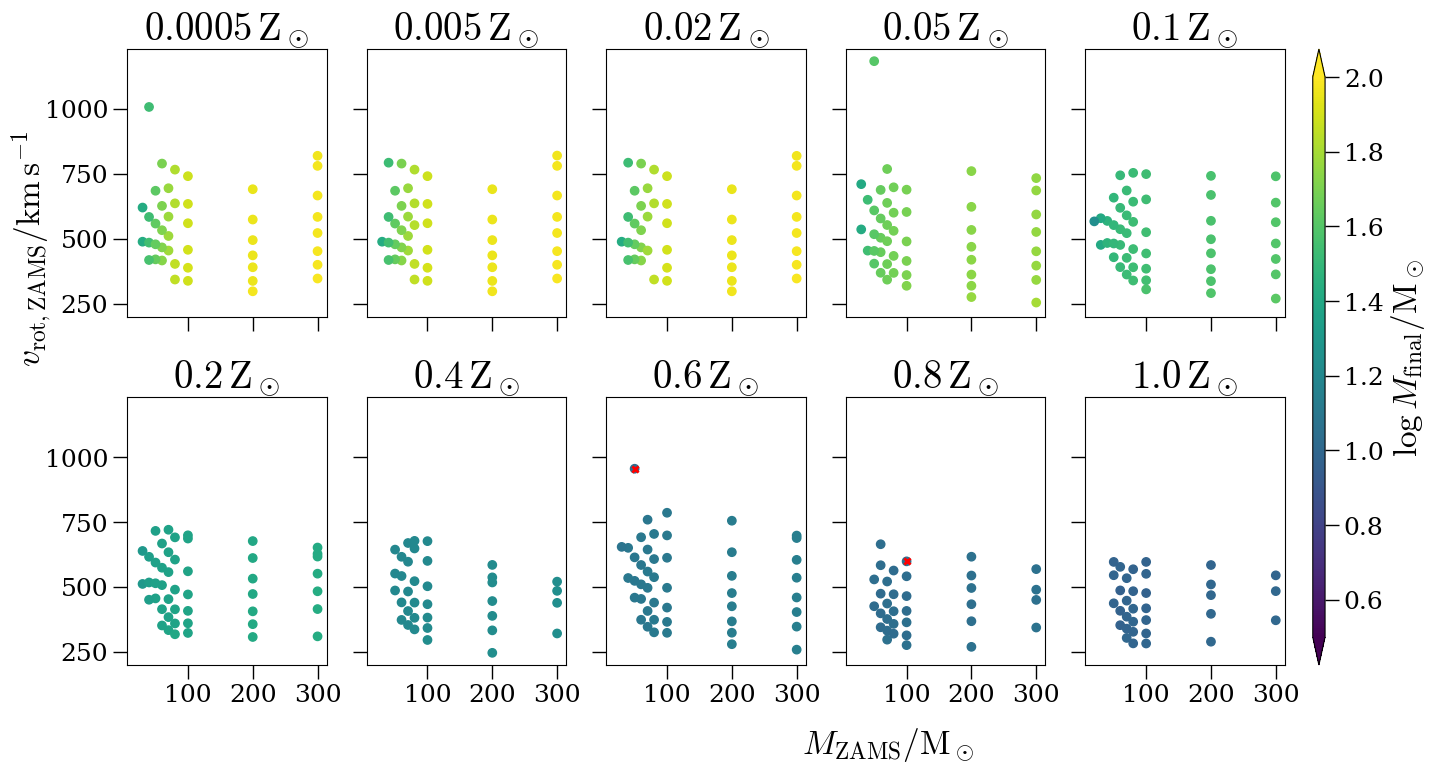

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.3)
mf_min = 0.5
mf_max = 2
cmap = cm.viridis

for ax, z_key in zip(axes.flatten(), core_props_df.z_key.unique()):
    ax.scatter(
        core_props_df[core_props_df.z_key==z_key].m_zams,
        core_props_df[core_props_df.z_key==z_key].v_rot_surf_zams,
        c=cmap(
            (np.log10(core_props_df[core_props_df.z_key==z_key].m_f) - mf_min) / (mf_max-mf_min))
    )
    ax.set_title(f'${z_key}\\,\\mathrm{{Z}}_\\odot$')
    
    crash_df = core_props_df[core_props_df.is_crash]
    ax.scatter(
        crash_df[crash_df.z_key==z_key].m_zams,
        crash_df[crash_df.z_key==z_key].v_rot_surf_zams,
        marker='x', c='red', s=20, label='crash'
    )
    
    nonche_df = core_props_df[~core_props_df.is_che]
    ax.scatter(
        nonche_df[nonche_df.z_key==z_key].m_zams,
        nonche_df[nonche_df.z_key==z_key].v_rot_surf_zams,
        marker='x', c='black', s=20, label='non-che'
    )
    
    crit_df = core_props_df[core_props_df.is_crit_at_zams]
    ax.scatter(
        crit_df[crit_df.z_key==z_key].m_zams,
        crit_df[crit_df.z_key==z_key].v_rot_surf_zams,
        marker='+', c='black', s=20, label='crit'
    )
    
fig.text(0.06, 0.5, '$v_\\mathrm{rot,ZAMS}/\\mathrm{km}\\,\\mathrm{s}^{-1}$', fontsize=24, rotation=90)
fig.text(0.5, 0, '$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)

sm = cm.ScalarMappable(norm=Normalize(vmin=mf_min, vmax=mf_max), cmap=cmap)
cb = fig.colorbar(sm, ax=axes, orientation='vertical', extend='both', pad=0.02, aspect=50)
cb.set_label('$\\log M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24)

#savefig(fig, 'che_windows_over_z_viridis')

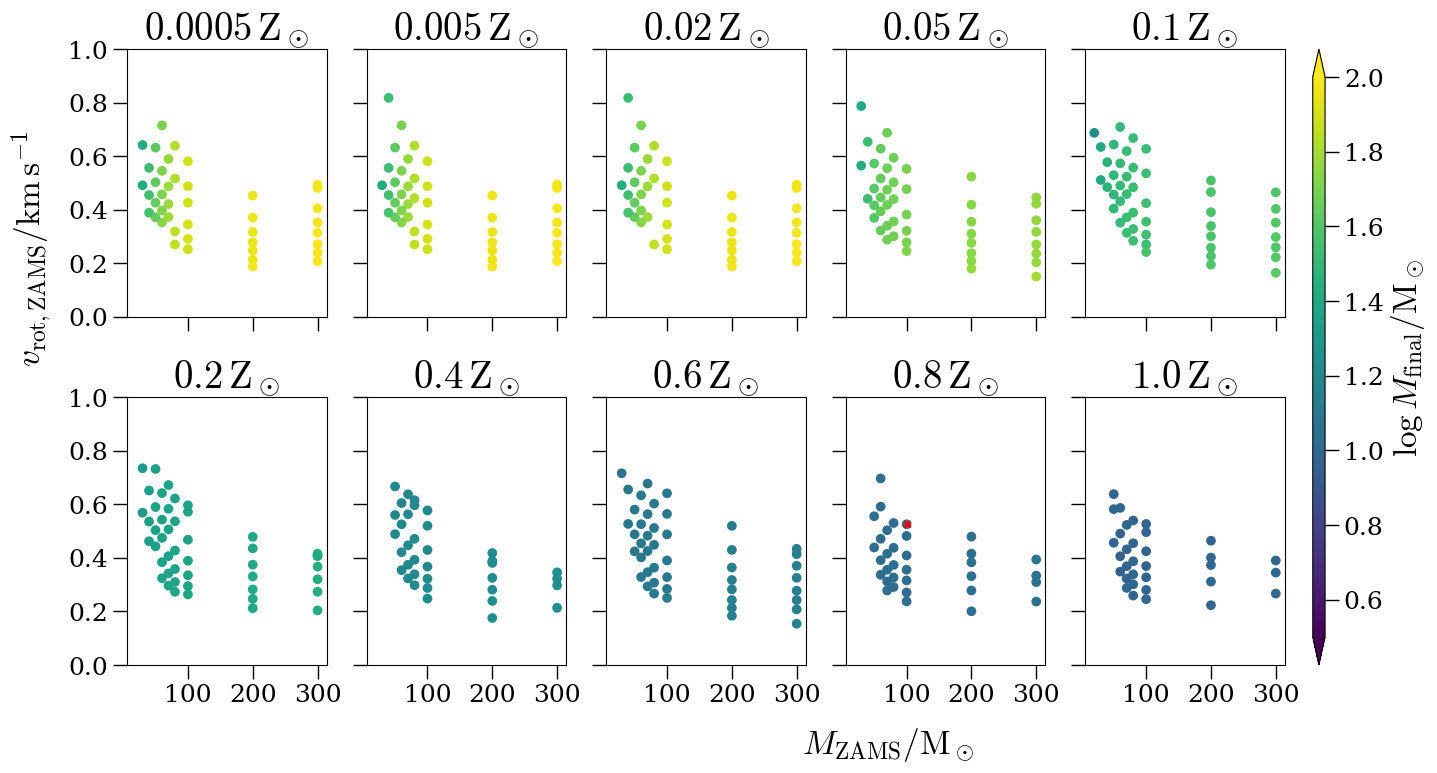

In [30]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.3)
mf_min = 0.5
mf_max = 2
cmap = cm.viridis

for ax, z_key in zip(axes.flatten(), core_props_df.z_key.unique()):
    ax.scatter(
        core_props_df[core_props_df.z_key==z_key].m_zams,
        core_props_df[core_props_df.z_key==z_key].v_rot_div_v_crit_zams,
        c=cmap(
            (np.log10(core_props_df[core_props_df.z_key==z_key].m_f) - mf_min) / (mf_max-mf_min))
    )
    ax.set_title(f'${z_key}\\,\\mathrm{{Z}}_\\odot$')
    
    crash_df = core_props_df[core_props_df.is_crash]
    ax.scatter(
        crash_df[crash_df.z_key==z_key].m_zams,
        crash_df[crash_df.z_key==z_key].v_rot_div_v_crit_zams,
        marker='x', c='red', s=20, label='crash'
    )
    
    nonche_df = core_props_df[~core_props_df.is_che]
    ax.scatter(
        nonche_df[nonche_df.z_key==z_key].m_zams,
        nonche_df[nonche_df.z_key==z_key].v_rot_div_v_crit_zams,
        marker='x', c='black', s=20, label='non-che'
    )
    
    crit_df = core_props_df[core_props_df.is_crit_at_zams]
    ax.scatter(
        crit_df[crit_df.z_key==z_key].m_zams,
        crit_df[crit_df.z_key==z_key].v_rot_div_v_crit_zams,
        marker='+', c='black', s=20, label='crit'
    )
    
    ax.set_ylim(0, 1)
fig.text(0.06, 0.5, '$v_\\mathrm{rot,ZAMS}/\\mathrm{km}\\,\\mathrm{s}^{-1}$', fontsize=24, rotation=90)
fig.text(0.5, 0, '$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)

sm = cm.ScalarMappable(norm=Normalize(vmin=mf_min, vmax=mf_max), cmap=cmap)
cb = fig.colorbar(sm, ax=axes, orientation='vertical', extend='both', pad=0.02, aspect=50)
cb.set_label('$\\log M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24)

#savefig(fig, 'che_windows_over_z_viridis')

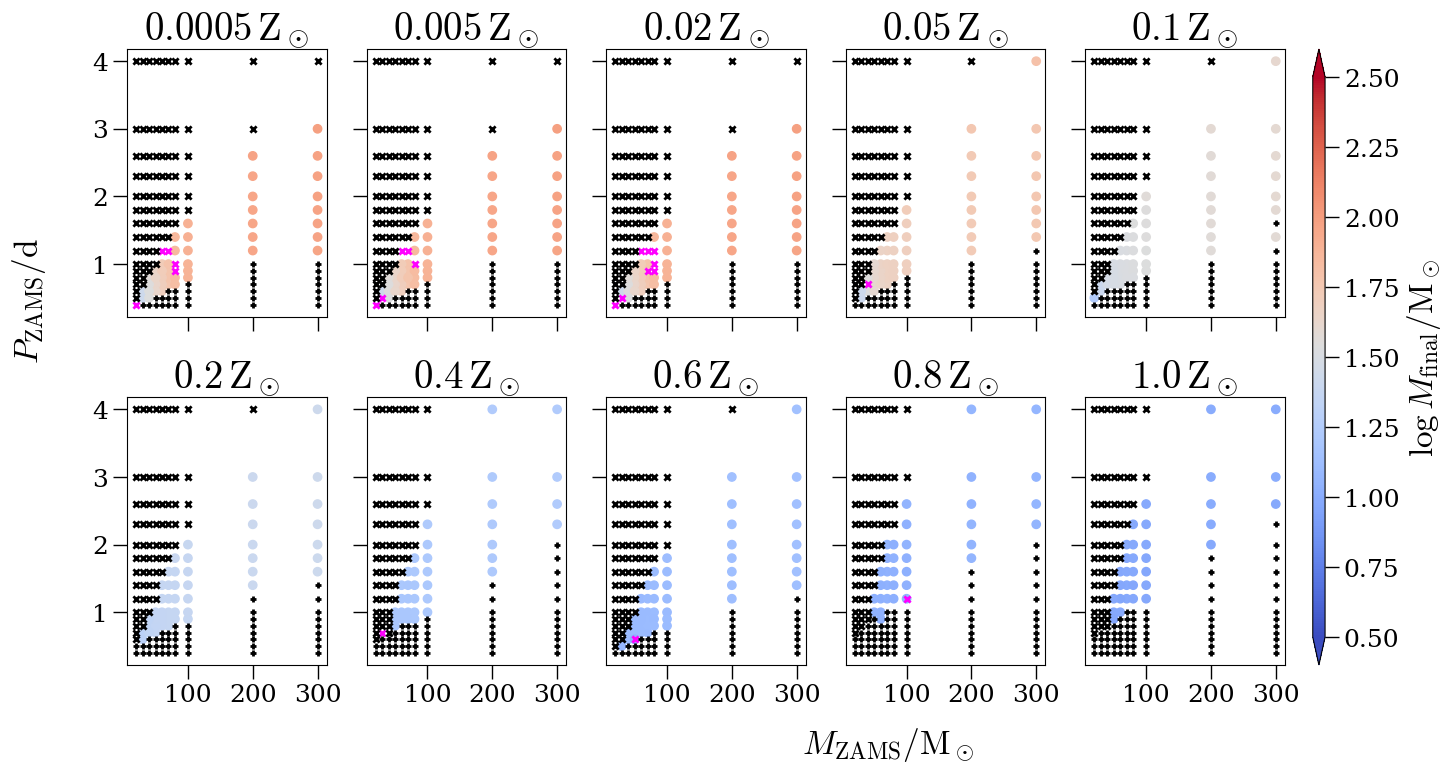

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.3)
mf_min = 0.5
mf_max = 2.5
cmap = build_logbump35_cmap(vmin=mf_min, vmax=mf_max, base_cmap=cm.coolwarm)

for ax, z_key in zip(axes.flatten(), core_props_df.z_key.unique()):  
    #ax.set_facecolor('lightgrey')
    ax.scatter(
        core_props_df[core_props_df.z_key==z_key].m_zams,
        core_props_df[core_props_df.z_key==z_key].p_spin_zams,
        marker='o',
        c=cmap(
            (np.log10(core_props_df[core_props_df.z_key==z_key].m_f) - mf_min) / (mf_max-mf_min)),
        ),
    
    ax.set_title(f'${z_key}\\,\\mathrm{{Z}}_\\odot$')
    
    crash_df = core_props_df[core_props_df.is_crash]
    ax.scatter(
        crash_df[crash_df.z_key==z_key].m_zams,
        crash_df[crash_df.z_key==z_key].p_spin_zams,
        marker='x', c='magenta', s=20, label='crash'
    )
    
    nonche_df = core_props_df[~core_props_df.is_che]
    ax.scatter(
        nonche_df[nonche_df.z_key==z_key].m_zams,
        nonche_df[nonche_df.z_key==z_key].p_spin_zams,
        marker='x', c='black', s=20, label='non-che'
    )
    
    crit_df = core_props_df[core_props_df.is_crit_at_zams]
    ax.scatter(
        crit_df[crit_df.z_key==z_key].m_zams,
        crit_df[crit_df.z_key==z_key].p_spin_zams,
        marker='+', c='black', s=20, label='crit'
    )
    
fig.text(0.06, 0.5, '$P_\\mathrm{ZAMS}/\\mathrm{d}$', fontsize=24, rotation=90)
fig.text(0.5, 0, '$M_\\mathrm{ZAMS}/\\mathrm{M}_\\odot$', fontsize=24)

sm = cm.ScalarMappable(norm=Normalize(vmin=mf_min, vmax=mf_max), cmap=cmap)
cb = fig.colorbar(sm, ax=axes, orientation='vertical', extend='both', pad=0.02, aspect=50)
cb.set_label('$\\log M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24)

#savefig(fig, 'che_windows_over_z_seismic')

In [28]:
class PMZLinearInterpolator:
    
    def __init__(self, data, var='m_f', bounds_error=False, fill_value=np.nan, verbose=False):
        self.data = data
        self.var = var
        self.bounds_error = bounds_error
        self.fill_value = fill_value
        self.verbose = verbose 
        self.p_interpolators = self._get_p_interpolators()       
        
    def _get_p_interpolators(self):
        """Sets p interpolators for all m_zams and z_key combinations."""
        p_interpolators = {}
        for z_key in self.data.z_key.unique():
            p_interpolators[z_key] = {}
            for m_key in self.data.m_zams.unique():
                p_interpolator = self._get_p_interpolator(m_key, z_key)
                p_interpolators[z_key][m_key] = p_interpolator
        return p_interpolators

    def _get_p_interpolator(self, m_key, z_key):
        ip_data = self.data.copy()
        ip_data = ip_data[ip_data.is_che & ~ip_data.is_merger_at_zams]
        
        m_zams = round(float(m_key), 1)
        ip_x = ip_data[
            (ip_data.z_key == z_key)
            & (ip_data.m_zams == m_zams)
        ].p_spin_zams.values
        ip_y = ip_data[
            (ip_data.z_key == z_key)
            & (ip_data.m_zams == m_zams)
        ][self.var].values
        
        if len(ip_x) == 0 or len(ip_y) == 0:
            if self.bounds_error:
                raise ValueError(f'No data for m_zams={m_zams}, z={z_key}')
            else:
                if self.verbose:
                    print(f'Warning: No data for m_zams={m_zams}, z_key={z_key}. Returning empty interpolator.')
                return interp1d([np.nan], [np.nan], bounds_error=False, fill_value=self.fill_value)
        
        ip_y = ip_y[ip_x.argsort()]
        ip_x = np.sort(ip_x)
        series = pd.Series(ip_y, index=ip_x)
        ip_y = series.interpolate(method='slinear', limit_area=None, limit_direction='both').values

        p_interpolator = interp1d(
            ip_x,
            ip_y,
            bounds_error=self.bounds_error,
            fill_value=self.fill_value
        )
        return p_interpolator

    def _get_m_interpolator(self, p_spin_zams, z_key):
        ip_x = []
        ip_y = []
        for m_key, p_interpolator in self.p_interpolators[z_key].items():
            ip_x.append(float(m_key))
            ip_y.append(p_interpolator(p_spin_zams))
        ip_x = np.array(ip_x)
        ip_y = np.array(ip_y)

        ip_y = ip_y[ip_x.argsort()]
        ip_x = np.sort(ip_x)    
        #series = pd.Series(ip_y, index=ip_x)
        #ip_y = series.interpolate(method='linear', limit_area='inside', limit_direction='both').values
                # Find indices where ip_y is nan and surrounded by non-nans

        m_interpolator = interp1d(
            ip_x, 
            ip_y, 
            bounds_error=self.bounds_error, 
            fill_value=self.fill_value
        )
        return m_interpolator
    
    def _get_z_interpolator(self, m_zams, p_spin_zams):
        ip_x = []
        ip_y = []
        for z_key in self.p_interpolators.keys():
            m_interpolator = self._get_m_interpolator(p_spin_zams, z_key)
            ip_x.append(np.log10(float(z_key)))
            ip_y.append(m_interpolator(m_zams))
        ip_x = np.array(ip_x)
        ip_y = np.array(ip_y)
            
        ip_y = ip_y[ip_x.argsort()]
        ip_x = np.sort(ip_x)
        #series = pd.Series(ip_y, index=ip_x)
        #ip_y = series.interpolate(method='linear', limit_area='inside', limit_direction='both').values
            
        logz_interpolator = interp1d(
            ip_x, 
            ip_y, 
            bounds_error=self.bounds_error, 
            fill_value=self.fill_value
        )
        def z_interpolator(z):
            return logz_interpolator(np.log10(z))
        
        return z_interpolator
    
    def get_var(self, m, p, z):
        interpolator = self._get_z_interpolator(m, p)
        return interpolator(z)
            

In [29]:
interpolator = PMZLinearInterpolator(core_props_df, var='m_f')

In [30]:
get_mf = np.vectorize(interpolator.get_var)

Text(0.5, 0, '$P_\\mathrm{ZAMS}/\\mathrm{d}$')

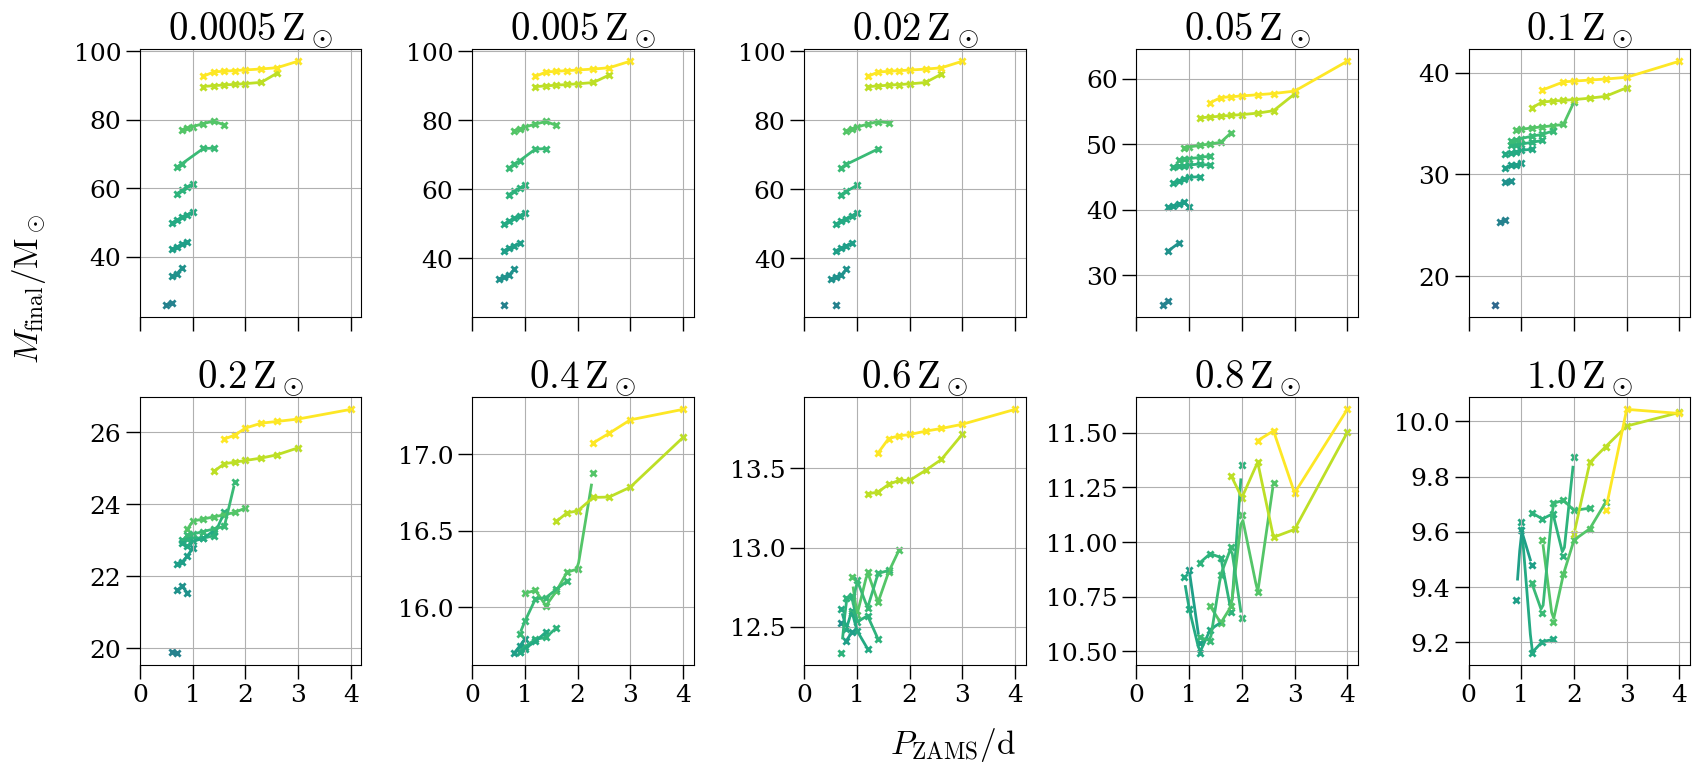

In [31]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
fig.subplots_adjust(hspace=0.3, wspace=0.5)
cmap = cm.viridis

for ax, z_key in zip(axes.flatten(), core_props_df.z_key.unique()):
    subdf = core_props_df[
        (core_props_df.z_key == z_key)
        & ~core_props_df.is_merger_at_zams
        ]
    for m in subdf.m_zams.unique():
        c = cmap((np.log10(m)-np.log10(5))/(np.log10(300)-np.log10(5)))
        subsubdf = subdf[subdf.m_zams == m]
        ax.scatter(subsubdf.p_spin_zams, subsubdf.m_f, color=c, marker='x', s=20)
        x = np.linspace(0, 4, 100)
        ax.plot(x, get_mf(m, x, float(z_key)), c=c)
    ax.set_xlim(0.1, 4.2)
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.grid()
    ax.set_title(f'${z_key}\\,\\mathrm{{Z}}_\\odot$')
    
#ax.set_yscale('log')
fig.text(0.06, 0.5, '$M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24, rotation=90)
fig.text(0.5, 0, '$P_\\mathrm{ZAMS}/\\mathrm{d}$', fontsize=24)

#savefig(fig, 'interpolator_consistency_check')

## An analytical fit for the boundaries of the CHE window

Text(0.5, 0, '$P_\\mathrm{ZAMS}/\\mathrm{d}$')

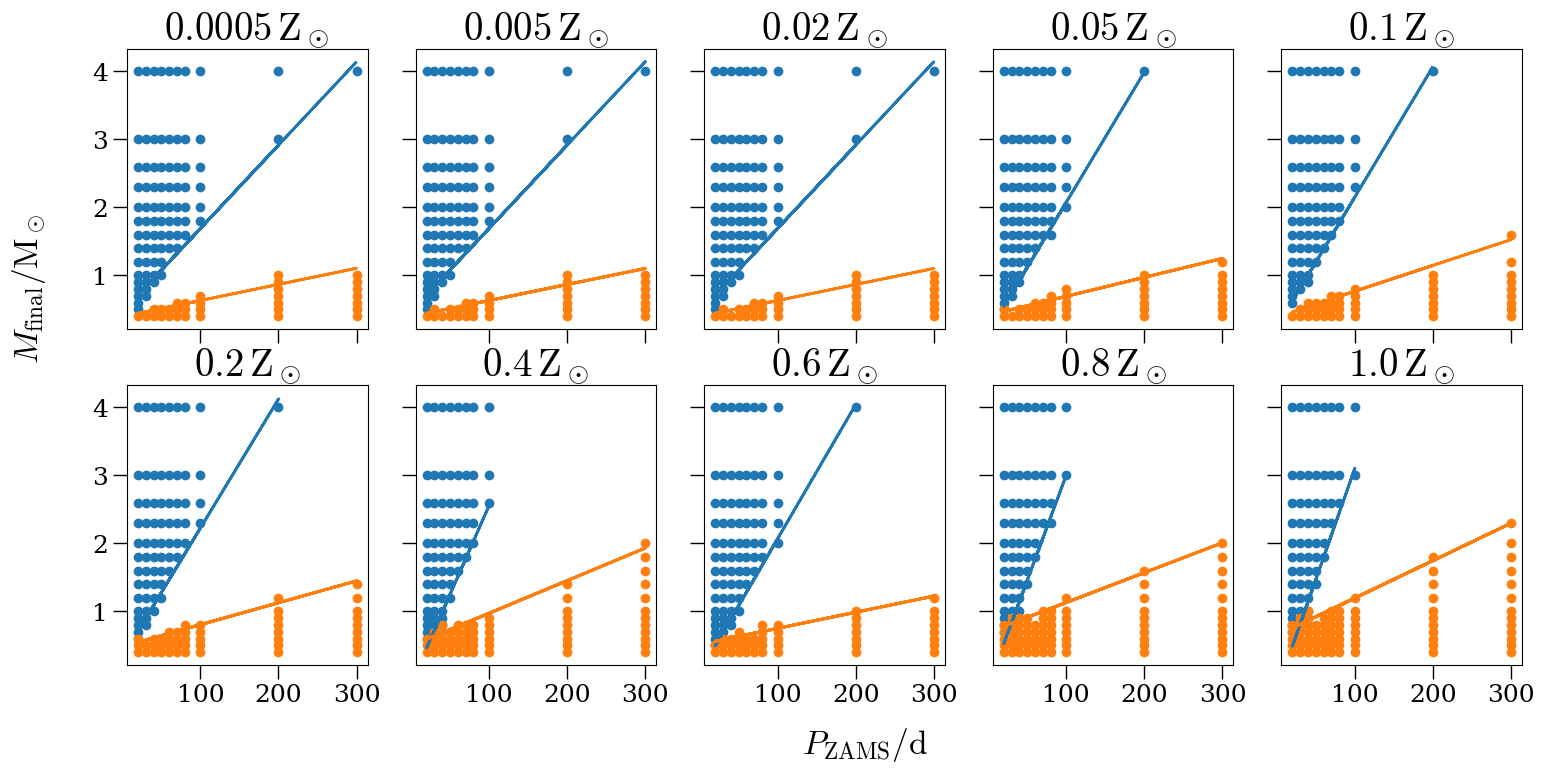

In [32]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharex=True, sharey=True)

che_window_upper_boundary_fits = np.zeros((len(core_props_df.z_key.unique()), 3))
for i, z_key in enumerate(core_props_df.z_key.unique()):
    subdf = core_props_df[(core_props_df.z_key==z_key)
                          & (~core_props_df.is_che)]
    x = []
    y = []
    for m in subdf.m_zams.unique():
        x.append(m)
        y.append(subdf[subdf.m_zams==m].p_spin_zams.min())
    slope, norm, *_ = linregress(x, y)
    che_window_upper_boundary_fits[i] = [np.log10(float(z_key)), slope, norm]
    axes.flatten()[i].plot(
        subdf.m_zams,
        slope*subdf.m_zams + norm)
    axes.flatten()[i].scatter(
        subdf.m_zams,
        subdf.p_spin_zams
    )
    
    
che_window_lower_boundary_fits = np.zeros((len(core_props_df.z_key.unique()), 3))
for i, z_key in enumerate(core_props_df.z_key.unique()):
    subdf = core_props_df[(core_props_df.z_key==z_key)
                          & (core_props_df.is_merger_at_zams)]
    x = []
    y = []
    for m in subdf.m_zams.unique():
        x.append(m)
        y.append(subdf[subdf.m_zams==m].p_spin_zams.max())
    slope, norm, *_ = linregress(x, y)
    che_window_lower_boundary_fits[i] = [np.log10(float(z_key)), slope, norm]
    axes.flatten()[i].plot(
        subdf.m_zams,
        slope*subdf.m_zams + norm)
    axes.flatten()[i].scatter(
        subdf.m_zams,
        subdf.p_spin_zams
    )

    axes.flatten()[i].set_title(f'${z_key}\\,\\mathrm{{Z}}_\\odot$')
    
fig.text(0.06, 0.5, '$M_\\mathrm{final}/\\mathrm{M}_\\odot$', fontsize=24, rotation=90)
fig.text(0.5, 0, '$P_\\mathrm{ZAMS}/\\mathrm{d}$', fontsize=24)

In [33]:
che_w_upper_bound_slope_ip = interp1d(
    che_window_upper_boundary_fits[:, 0],
    che_window_upper_boundary_fits[:, 1],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)
che_w_upper_bound_norm_ip = interp1d(
    che_window_upper_boundary_fits[:, 0],
    che_window_upper_boundary_fits[:, 2],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)
che_w_lower_bound_slope_ip = interp1d(
    che_window_lower_boundary_fits[:, 0],
    che_window_lower_boundary_fits[:, 1],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)
che_w_lower_bound_norm_ip = interp1d(
    che_window_lower_boundary_fits[:, 0],
    che_window_lower_boundary_fits[:, 2],
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate'
)


Text(0, 0.5, 'Norm')

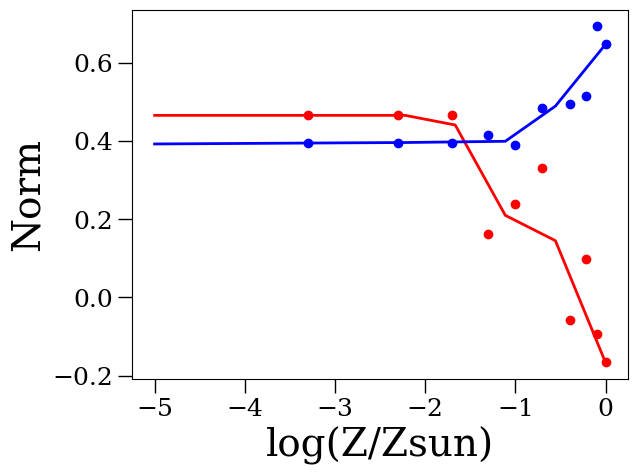

In [34]:
plot_logzs = np.linspace(-5, 0, 10)
plt.scatter(
    che_window_upper_boundary_fits[:, 0],
    che_window_upper_boundary_fits[:, 2],
    color='r'
)
plt.plot(
    plot_logzs,
    che_w_upper_bound_norm_ip(plot_logzs),
    'r'
)

plt.scatter(
    che_window_lower_boundary_fits[:, 0],
    che_window_lower_boundary_fits[:, 2],
    color='b'
)
plt.plot(
    plot_logzs,
    che_w_lower_bound_norm_ip(plot_logzs),
    'b'
)
plt.xlabel('log(Z/Zsun)')
plt.ylabel('Norm')

Text(0, 0.5, 'Slope')

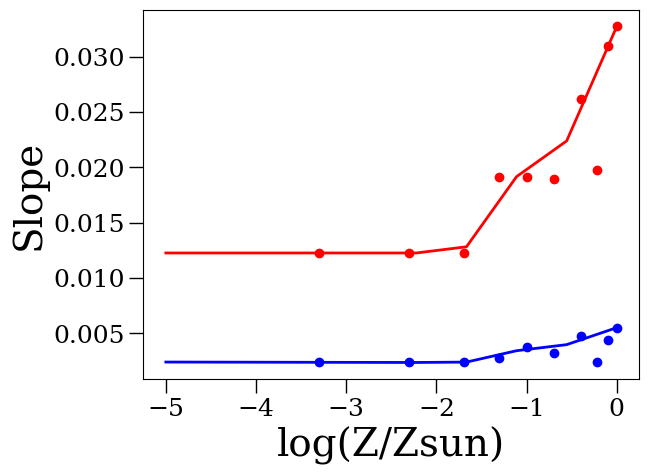

In [35]:
plot_logzs = np.linspace(-5, 0, 10)
plt.scatter(
    che_window_upper_boundary_fits[:, 0],
    che_window_upper_boundary_fits[:, 1],
    color='r'
)
plt.plot(
    plot_logzs,
    che_w_upper_bound_slope_ip(plot_logzs),
    'r'
)

plt.scatter(
    che_window_lower_boundary_fits[:, 0],
    che_window_lower_boundary_fits[:, 1],
    color='b'
)
plt.plot(
    plot_logzs,
    che_w_lower_bound_slope_ip(plot_logzs),
    'b'
)
plt.xlabel('log(Z/Zsun)')
plt.ylabel('Slope')

In [36]:
@np.vectorize
def is_in_che_window(m, p, logz):
    max_p = che_w_upper_bound_slope_ip(logz)*m + che_w_upper_bound_norm_ip(logz)
    min_p = che_w_lower_bound_slope_ip(logz)*m + che_w_lower_bound_norm_ip(logz)
    if p < max_p and p > min_p:
        return True
    else:
        return False

These fits are particularly useful for interpolators that do not already integrate the boundaries (i.e., yield nan outside of the CHE window), but this is not the case for our custom interpolator.

## Interpolating from the grids to a synthetic population

In [37]:
def interpolate(job, data, var):
    """Pickable function to interpolate from a pop array.
    
    Job is a (n_pop, n_var) array where n_var > 3. job[:,0] contains
    metallicities, job[:,1] contains m_zams and job[:,2] contains 
    p_spin_zams.
    """
    
    interpolator = PMZLinearInterpolator(data, var=var)
    vec_f = np.vectorize(interpolator.get_var)
    result = vec_f(job[:, 1], job[:, 2], job[:, 0])
    return result

def parallel_set_sample_var(sample, var, var_col_i, data, n_processes):
    run_job = partial(interpolate, data=data, var=var)
    
    with ProcessPoolExecutor(max_workers=n_processes) as executor:
        jobs = np.array_split(sample, n_processes)
        futures = {
            executor.submit(run_job, job): job_index for job_index, job in enumerate(jobs)
        }
        
        for future in tqdm(as_completed(futures), total=len(futures), desc=f'Collecting {var}'):
            job_index = futures[future]
            try:
                result = future.result()
            except Exception as e:
                print(f'Error in job {job_index}: {e}')
                continue
            sample[job_index*len(result):(job_index+1)*len(result), var_col_i] = result
    return sample

def draw_pop(
    data,
    res=int(1e8),
    min_m=20,
    max_m=300,
    min_p=0.1,
    max_p=4,
    min_zdivzsun=0.1,
    max_zdivzsun=1.0,
    fixed_z=None,
    n_processes=36,
    vars=[
        'm_f',
        'x_f',
        't_d'
    ]
):
    sample_masses = np.linspace(min_m, max_m, res)
    sample_probs = sample_masses**-2.3/np.sum(sample_masses**-2.3)
    sample_masses = np.random.choice(sample_masses, p=sample_probs, size=int(res/100))

    sample_periods = np.linspace(np.log10(min_p), np.log10(max_p), res)
    sample_probs = np.ones(res)/res
    sample_periods = 10.**np.random.choice(sample_periods, p=sample_probs, size=int(res/100))
    
    if fixed_z is not None:
        sample_zs = np.tile(fixed_z, int(res/100))
    else:
        sample_zs = np.linspace(np.log10(min_zdivzsun), np.log10(max_zdivzsun), res)
        sample_probs = np.ones(res)/res
        sample_zs = 10.**np.random.choice(sample_zs, p=sample_probs, size=int(res/100))

    # The first three columns of the sample array should aways be 
    # metallicity, m_zams and p_spin_zams, otherwise the 
    # parallel_set_sample_var function will not work.
    sample = np.array([
        sample_zs, 
        sample_masses, 
        sample_periods,
        *np.zeros((len(vars), int(res/100)))
        ]).T
    
    for i_var, var in enumerate(vars):
        i_var += 3
        sample = parallel_set_sample_var(
            sample=sample,
            var=var,
            var_col_i=i_var,
            data=data,
            n_processes=n_processes
        )
    
    return sample

In [38]:
res=int(1e8)
min_m=10
max_m=300
min_p=0.1
max_p=4
min_zdivzsun=0.0005
max_zdivzsun=1.0
fixed_z=None
n_processes=96
vars=[
    'm_f',
    'p_orb_f',
    'x_f',
    'min_x_f',
    'log_t_d'
]

sample = draw_pop(
    data=core_props_df,
    res=res,
    min_m=min_m,
    max_m=max_m,
    min_p=min_p,
    max_p=max_p,
    min_zdivzsun=min_zdivzsun,
    max_zdivzsun=max_zdivzsun,
    fixed_z=fixed_z,
    n_processes=n_processes,
    vars=vars
)

(0.0, 0.04)

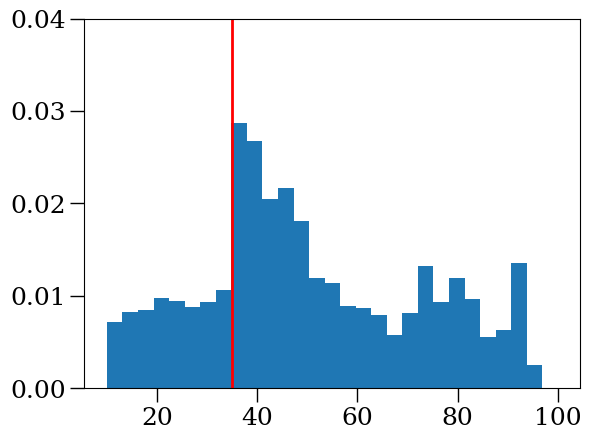

In [39]:
plt.hist(sample[:, 3], bins=np.linspace(10, 100, 30), density=True)
plt.vlines(35, 0, 1, color='red', label='35 Msun')
plt.ylim(0, 0.04)

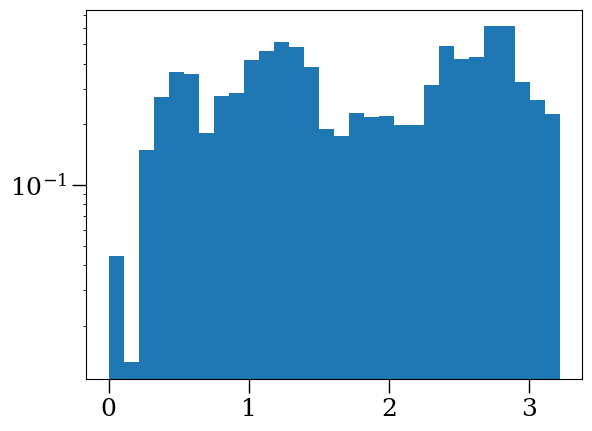

In [ ]:
plt.hist(sample[:, 5], bins=30, density=True)
#plt.vlines(35, 0, 1, color='red', label='35 Msun')
plt.yscale('log')

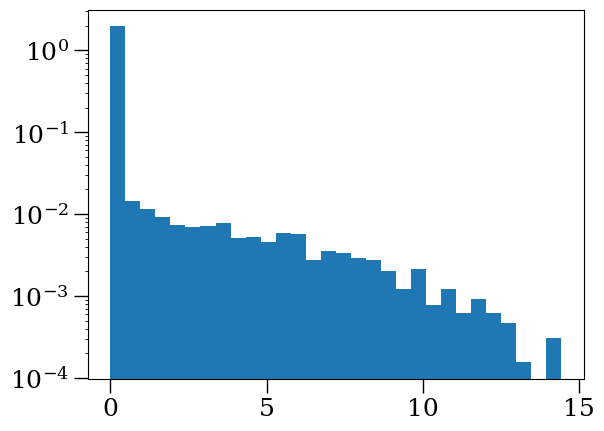

In [ ]:
plt.hist(sample[:, 6], bins=30, density=True)
#plt.vlines(35, 0, 1, color='red', label='35 Msun')
plt.yscale('log')

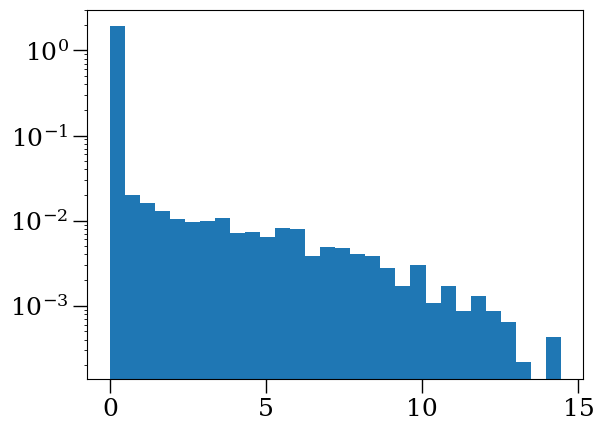

In [ ]:
plt.hist(msample[:, -2], bins=30, density=True)
#plt.vlines(35, 0, 1, color='red', label='35 Msun')
plt.yscale('log')

(array([6.400e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 6.517e+03, 1.255e+03, 9.660e+02, 9.120e+02, 9.260e+02,
        6.110e+02, 5.060e+02, 5.150e+02, 4.100e+02, 3.360e+02, 1.760e+02,
        9.400e+01, 7.300e+01, 4.800e+01, 3.700e+01, 1.500e+01, 3.000e+00]),
 array([ 0.        ,  0.59887947,  1.19775895,  1.79663842,  2.39551789,
         2.99439737,  3.59327684,  4.19215631,  4.79103579,  5.38991526,
         5.98879473,  6.5876742 ,  7.18655368,  7.78543315,  8.38431262,
         8.9831921 ,  9.58207157, 10.18095104, 10.77983052, 11.37870999,
        11.97758946, 12.57646894, 13.17534841, 13.77422788, 14.37310736,
        14.97198683, 15.5708663 , 16.16974578, 16.76862525, 17.36750472,
        17.9663842 ]),
 <BarContainer object of 30 artists>)

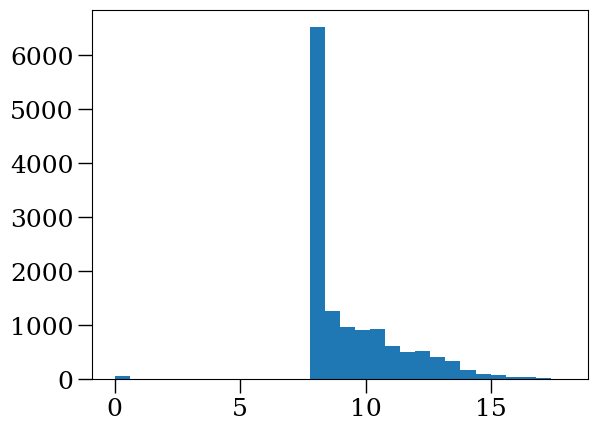

In [ ]:
plt.hist(sample[:, -1], bins=30)

msample = sample[sample[:, -1] <= np.log10(t_h)]

np.save(DATA_DIR/f'ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w.npy', sample)
print(f'Saved sample with {len(sample)} stars to {DATA_DIR/f"ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w.npy"}')
np.save(DATA_DIR/f'ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w_mergers_only.npy', msample)
print(f'Saved sample with {len(msample)} stars to {DATA_DIR/f"ip_pop_minz{min_zdivzsun}_maxz{max_zdivzsun}_res{res:.0e}_enhanced_w_mergers_only.npy"}')

In [55]:
sample[:, 4]

array([1.39678237e+09,            nan,            nan, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])

(array([105.,  34.,  52.,  49.,  52.,  46.,  40.,  21.,  16.,   5.]),
 array([ 7.79531205,  8.84252285,  9.88973364, 10.93694444, 11.98415524,
        13.03136604, 14.07857683, 15.12578763, 16.17299843, 17.22020923,
        18.26742002]),
 <BarContainer object of 10 artists>)

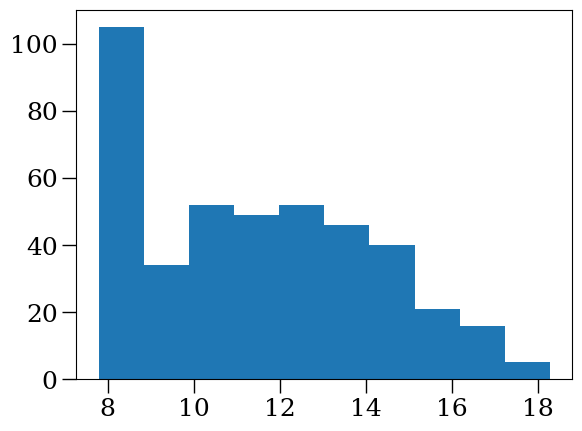

In [60]:
plt.hist(np.log10(core_props_df.t_d))

AttributeError: 'Figure' object has no attribute 'xscale'

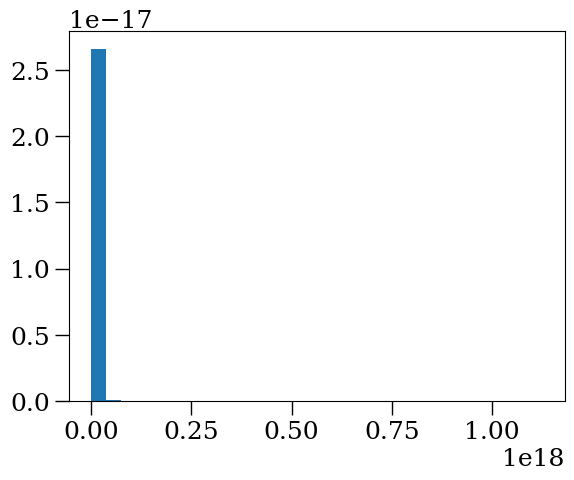

In [57]:
plt.hist(sample[:, 4], bins=30, density=True)
#plt.vlines(35, 0, 1, color='red', label='35 Msun')
#plt.ylim(0, 0.04)
fig.xscale('log')

(0.0, 0.1)

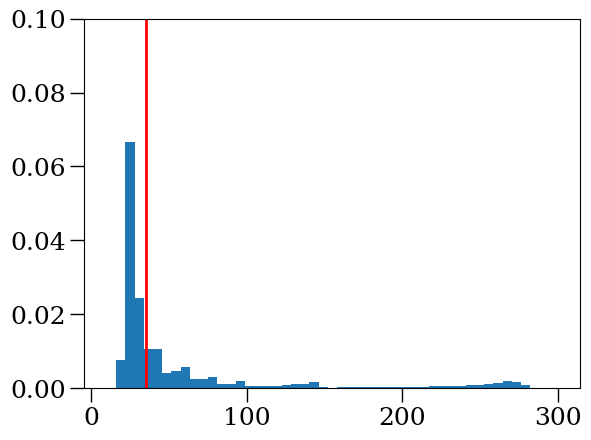

In [ ]:
plt.hist(rbf(sample[:,:3]), bins=np.linspace(10, 300, 50), density=True)
plt.vlines(35, 0, 1, color='red', label='35 Msun')
plt.ylim(0, 0.1)

(array([7143., 1025.,  500.,  170.,  309.,   61.,   86.,  128.,  184.,
         394.]),
 array([ 20.42139053,  46.46998453,  72.51857853,  98.56717253,
        124.61576653, 150.66436052, 176.71295452, 202.76154852,
        228.81014252, 254.85873652, 280.90733051]),
 <BarContainer object of 10 artists>)

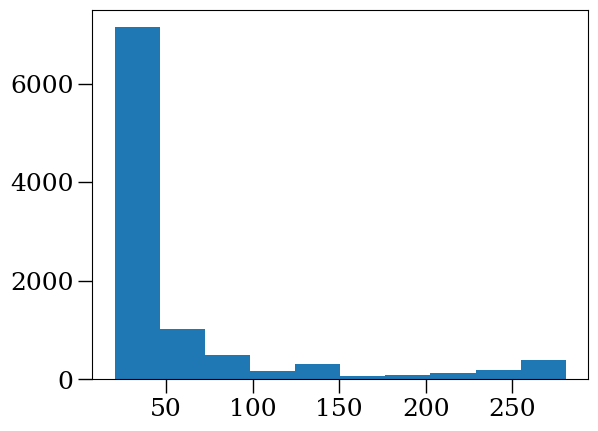

: 

In [ ]:
plt.hist(sample[:, 4])